# HW02: Life Expectancy

Регрессия ожидаемой продолжительности жизни.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
data_path = Path("data/life_expectancy.xls")
raw_data = pd.read_excel(data_path)
raw_data.columns = raw_data.columns.str.strip().str.replace("  ", " ", regex=False).str.replace(" ", "_", regex=False).str.lower()
raw_data = raw_data.rename(columns={"life_expectancy": "life_expectancy"})
raw_data.head()

,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,measles,bmi,under-five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness_1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
0,65.0,201.50,62,2.50,71.2796,1154,76.50,83,6,8.16,93.50,0.1,584.2592,33736494,17.2,17.3,0.9800,10.1
1,59.9,195.89,64,9.13,73.5236,492,86.19,86,58,8.18,86.87,0.1,612.6965,327582,17.5,17.5,0.9188,10.0
2,59.9,195.89,66,9.13,73.2192,430,60.96,89,62,8.13,86.87,0.1,631.7450,31731688,17.7,17.7,0.9188,9.9
3,59.5,195.45,69,9.65,78.1842,2787,60.80,93,67,8.52,86.35,0.1,669.9590,3696958,17.9,18.0,0.9140,9.8
4,59.2,195.12,71,10.04,7.0971,3013,60.68,97,68,7.87,85.96,0.1,63.5372,2978599,18.2,18.2,0.9104,9.5


In [3]:
missing_summary = raw_data.isna().sum().to_frame("missing_values")
missing_summary["missing_share"] = missing_summary["missing_values"] / len(raw_data)
missing_summary

,missing_values,missing_share
life_expectancy,0,0.0
adult_mortality,0,0.0
infant_deaths,0,0.0
alcohol,0,0.0
percentage_expenditure,0,0.0
measles,0,0.0
bmi,0,0.0
under-five_deaths,0,0.0
polio,0,0.0
total_expenditure,0,0.0


In [4]:
data = raw_data.dropna().copy()
target_name = "life_expectancy"
feature_names = [column for column in data.columns if column != target_name]

x = data[feature_names]
y = data[target_name]

summary_table = data.describe().T
summary_table

,count,mean,std,min,25%,50%,75%,max
life_expectancy,86.0,6.6887e+01,1.0847e+01,45.3000,5.7300e+01,7.3450e+01,7.5400e+01,7.7800e+01
adult_mortality,86.0,2.0301e+02,1.2044e+01,179.8300,1.9245e+02,2.1047e+02,2.1283e+02,2.1558e+02
infant_deaths,86.0,3.4651e+01,3.7138e+01,0.0000,1.0000e+00,2.0000e+01,7.4750e+01,9.7000e+01
alcohol,86.0,2.2084e+01,1.2014e+01,2.5000,1.6290e+01,1.7775e+01,2.0085e+01,5.0170e+01
percentage_expenditure,86.0,2.8852e+02,2.1506e+02,1.3886,2.7562e+02,3.1241e+02,3.1542e+02,1.5043e+03
measles,86.0,1.4739e+03,2.9680e+03,0.0000,0.0000e+00,6.5500e+01,1.4108e+03,1.5374e+04
bmi,86.0,6.0822e+01,7.3620e+00,48.4400,5.5870e+01,6.0480e+01,6.6850e+01,8.6190e+01
under-five_deaths,86.0,4.9919e+01,5.6558e+01,0.0000,1.0000e+00,2.3000e+01,1.0900e+02,1.6000e+02
polio,86.0,7.7581e+01,2.8066e+01,3.0000,6.4250e+01,9.3000e+01,9.8000e+01,9.9000e+01
total_expenditure,86.0,5.3879e+00,1.8652e+00,0.0000,4.2025e+00,5.3500e+00,6.2675e+00,9.4200e+00


## Базовая модель

OLS оценивает линейную связь между ожидаемой продолжительностью жизни и всеми доступными факторами.

In [5]:
x_with_constant = sm.add_constant(x)
full_model = sm.OLS(y, x_with_constant).fit()
full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.806e+04
Date:                Tue, 25 Aug 2026   Prob (F-statistic):          2.86e-117
Time:                        01:07:12   Log-Likelihood:                 35.320
No. Observations:                  86   AIC:                            -34.64
Df Residuals:                      68   BIC:                             9.537
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                             -10.2158      1.561     -6.546      0.000     -13.330      -7.102
adult_mortality                     0.0017      0.007      0.242      0.809      -0.012       0.015
infant_deaths                      -0.0025      0.016     -0.160      0.873      -0.034       0.029
alcohol                             0.0090      0.010      0.935      0.353      -0.010       0.028
percentage_expenditure          -3.995e-05      0.000     -0.281      0.780      -0.000       0.000
measles                         -6.555e-08   8.63e-06     -0.008      0.994   -1.73e-05    1.72e-05
bmi                                 0.0332      0.005      7.074      0.000       0.024       0.043
under-five_deaths                   0.0050      0.011      0.440      0.661      -0.018       0.027
polio                               0.0015      0.002      0.870      0.387      -0.002       0.005
total_expenditure                  -0.0008      0.021     -0.039      0.969      -0.042       0.040
diphtheria                          0.7869      0.015     51.177      0.000       0.756       0.818
hiv/aids                            0.0294      0.138      0.213      0.832      -0.246       0.305
gdp                              8.559e-06   8.93e-06      0.959      0.341   -9.26e-06    2.64e-05
population                      -2.605e-10   1.88e-09     -0.138      0.890   -4.01e-09    3.49e-09
thinness_1-19_years                -0.0026      0.011     -0.234      0.816      -0.024       0.019
thinness_5-9_years                  0.0036      0.010      0.350      0.727      -0.017       0.024
income_composition_of_resources    -0.7903      0.209     -3.775      0.000      -1.208      -0.373
schooling                          -0.0515      0.024     -2.171      0.033      -0.099      -0.004
==============================================================================
Omnibus:                       47.469   Durbin-Watson:                   1.407
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              342.797
Skew:                          -1.429   Prob(JB):                     3.65e-75
Kurtosis:                      12.354   Cond. No.                     1.45e+09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.45e+09. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [6]:
coefficients_table = full_model.summary2().tables[1]
important_coefficients = coefficients_table.loc[coefficients_table["P>|t|"] < 0.2].sort_values("P>|t|")
important_coefficients

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
diphtheria,0.7869,0.0154,51.1769,5.0036e-56,0.7563,0.8176
bmi,0.0332,0.0047,7.0744,1.0419e-09,0.0238,0.0425
const,-10.2158,1.5605,-6.5464,9.2191e-09,-13.3297,-7.1018
income_composition_of_resources,-0.7903,0.2093,-3.7752,3.3824e-04,-1.2081,-0.3726
schooling,-0.0515,0.0237,-2.1708,3.3437e-02,-0.0989,-0.0042


In [7]:
vif_table = pd.DataFrame(
    {
        "feature": x_with_constant.columns,
        "vif": [variance_inflation_factor(x_with_constant.values, index) for index in range(x_with_constant.shape[1])],
    }
)
vif_table.replace([np.inf, -np.inf], np.nan).sort_values("vif", ascending=False)

,feature,vif
0,const,6430.6068
7,under-five_deaths,1057.7286
2,infant_deaths,893.4297
10,diphtheria,127.1849
11,hiv/aids,39.6244
3,alcohol,34.6539
1,adult_mortality,17.9910
17,schooling,15.8164
14,thinness_1-19_years,11.2623
16,income_composition_of_resources,9.4162


In [8]:
residuals = full_model.resid
fitted_values = full_model.fittedvalues
bp_statistic, bp_pvalue, bp_fvalue, bp_fpvalue = het_breuschpagan(residuals, full_model.model.exog)

diagnostics_table = pd.DataFrame(
    {
        "test": ["Shapiro-Wilk", "Breusch-Pagan LM", "Breusch-Pagan F"],
        "statistic": [st.shapiro(residuals).statistic, bp_statistic, bp_fvalue],
        "p_value": [st.shapiro(residuals).pvalue, bp_pvalue, bp_fpvalue],
    }
)
diagnostics_table

,test,statistic,p_value
0,Shapiro-Wilk,0.7634,1.8821e-10
1,Breusch-Pagan LM,54.6490,7.8006e-06
2,Breusch-Pagan F,6.9725,2.4878e-09


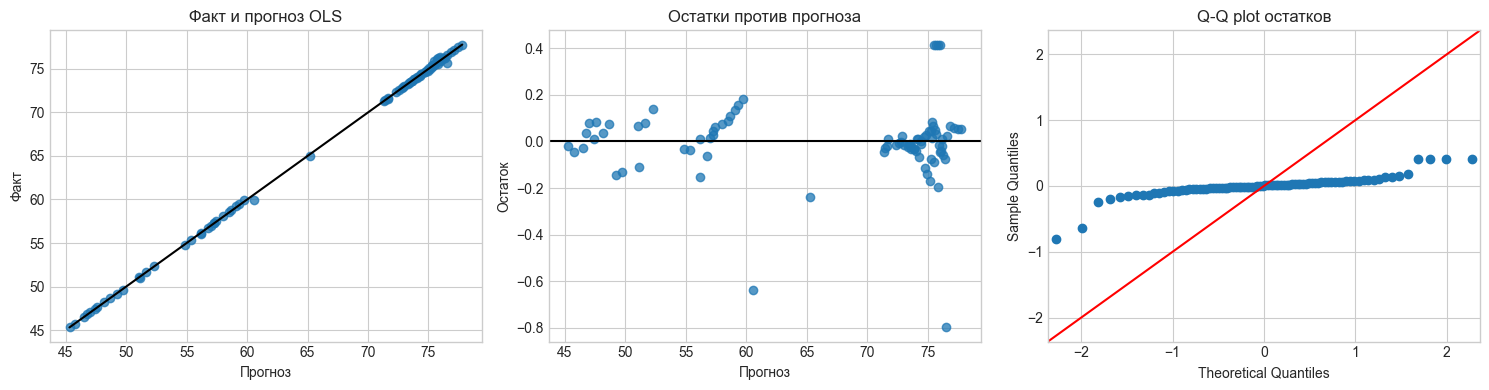

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(fitted_values, y, alpha=0.75)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], color="black")
axes[0].set_title("Факт и прогноз OLS")
axes[0].set_xlabel("Прогноз")
axes[0].set_ylabel("Факт")

axes[1].scatter(fitted_values, residuals, alpha=0.75)
axes[1].axhline(0, color="black")
axes[1].set_title("Остатки против прогноза")
axes[1].set_xlabel("Прогноз")
axes[1].set_ylabel("Остаток")

sm.qqplot(residuals, line="45", ax=axes[2])
axes[2].set_title("Q-Q plot остатков")

plt.tight_layout()

In [10]:
correlations = data.corr(numeric_only=True)[target_name].drop(target_name).sort_values(key=np.abs, ascending=False)
correlations.to_frame("correlation_with_life_expectancy")

,correlation_with_life_expectancy
diphtheria,0.9992
under-five_deaths,-0.9776
infant_deaths,-0.9582
adult_mortality,0.9523
schooling,0.8465
polio,0.8301
hiv/aids,-0.7836
alcohol,-0.7059
income_composition_of_resources,0.6006
gdp,0.4750


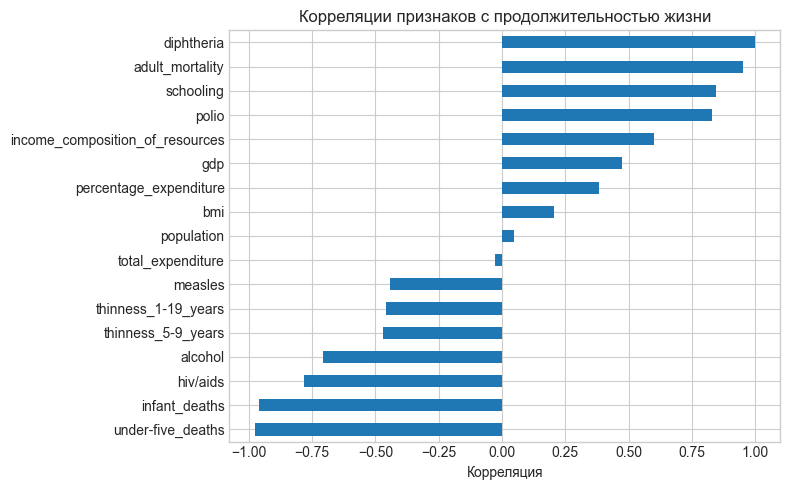

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
correlations.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Корреляции признаков с продолжительностью жизни")
ax.set_xlabel("Корреляция")
ax.set_ylabel("")
plt.tight_layout()

## Сравнение моделей

Сравним обычную регрессию с регуляризацией на кросс-валидации.

In [12]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "OLS": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 40))),
    "Lasso": make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-3, 1, 60), cv=cv, max_iter=20000, random_state=42)),
}

comparison_rows = []
for model_name, model in models.items():
    predicted = cross_val_predict(model, x, y, cv=cv)
    comparison_rows.append(
        {
            "model": model_name,
            "cv_r2": r2_score(y, predicted),
            "cv_rmse": mean_squared_error(y, predicted) ** 0.5,
            "cv_mae": mean_absolute_error(y, predicted),
        }
    )

model_comparison = pd.DataFrame(comparison_rows).sort_values("cv_rmse")
model_comparison

,model,cv_r2,cv_rmse,cv_mae
1,Ridge,0.9104,3.2274,0.5978
0,OLS,0.9008,3.3964,0.6224
2,Lasso,0.8986,3.4337,0.8083


In [13]:
best_pipeline = models[model_comparison.iloc[0]["model"]]
best_pipeline.fit(x, y)

linear_step = best_pipeline.named_steps[list(best_pipeline.named_steps.keys())[-1]]
feature_effects = pd.DataFrame(
    {
        "feature": feature_names,
        "standardized_coefficient": linear_step.coef_,
    }
).sort_values("standardized_coefficient")

feature_effects

,feature,standardized_coefficient
15,income_composition_of_resources,-0.2237
16,schooling,-0.1665
1,infant_deaths,-0.0845
13,thinness_1-19_years,-0.0162
3,percentage_expenditure,-0.0079
12,population,-0.0030
8,total_expenditure,-0.0015
4,measles,-0.0006
14,thinness_5-9_years,0.0201
0,adult_mortality,0.0233


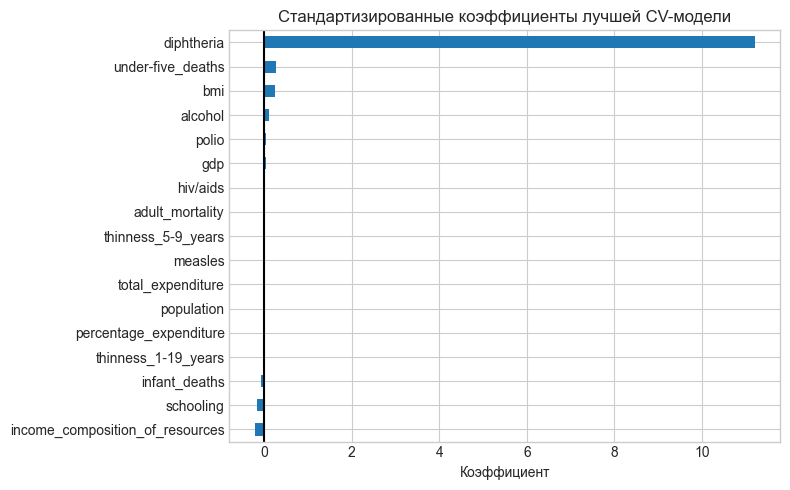

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
feature_effects.plot(x="feature", y="standardized_coefficient", kind="barh", ax=ax, legend=False)
ax.axvline(0, color="black")
ax.set_title("Стандартизированные коэффициенты лучшей CV-модели")
ax.set_xlabel("Коэффициент")
ax.set_ylabel("")
plt.tight_layout()

## Вывод

Сильнее всего с продолжительностью жизни связаны смертность взрослых, ВИЧ/СПИД, школьное образование и показатель дохода. Диагностика нужна, потому что часть признаков заметно коррелирует между собой, поэтому регуляризация даёт более устойчивую модель.